READ ME

Application research of machine learning in functional magnetic resonance imaging (fMRI) data analysis

I've tried to combine two parts of nilearn turorials
- Deriving spatial maps from group fMRI data using ICA and Dictionary Learning
- Computing a connectome with sparse inverse covariance

which original source
https://nilearn.github.io/auto_examples/index.html
https://nilearn.github.io/auto_examples/03_connectivity/plot_compare_decomposition.html#sphx-glr-auto-examples-03-connectivity-plot-compare-decomposition-py
https://nilearn.github.io/auto_examples/03_connectivity/plot_inverse_covariance_connectome.html#sphx-glr-auto-examples-03-connectivity-plot-inverse-covariance-connectome-py


edt, LOK

last update
20-04-21

In [ ]:
from nilearn import datasets

rest_dataset = datasets.fetch_development_fmri(n_subjects=30)
func_filenames = rest_dataset.func
print('First functional nifti image (4D) is at: %s' %
      rest_dataset.func[0])

# ICA

canICA

In [ ]:
from nilearn.decomposition import CanICA

canica = CanICA(n_components=20,
                memory="nilearn_cache", memory_level=2,
                verbose=10,
                mask_strategy='template',
                random_state=0)
canica.fit(func_filenames)

# Retrieve the independent components in brain space. Directly
# accesible through attribute `components_img_`.

canica_components_img = canica.components_img_

# components_img is a Nifti Image object, and can be saved to a file with
# the following line:

canica_components_img.to_filename('canica0251_resting_state.nii.gz')

## plotting ICA

from nilearn.plotting import plot_prob_atlas

# Plot all ICA components together

plot_prob_atlas(canica_components_img, title='All ICA components')

F:\Users\pc\anaconda3\lib\site-packages\nilearn\plotting\displays.py:1750: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax = fh.add_axes([fraction * index * (x1 - x0) + x0, y0,


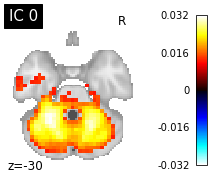

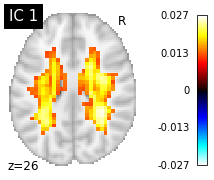

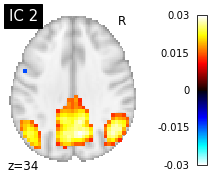

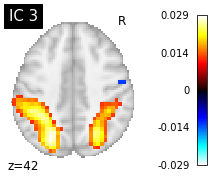

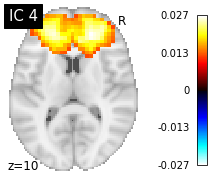

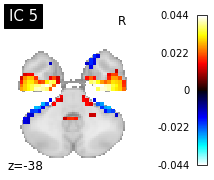

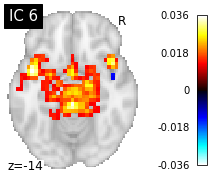

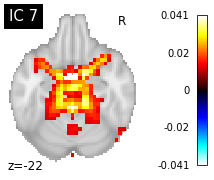

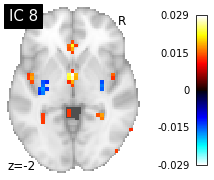

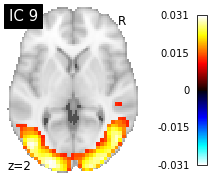

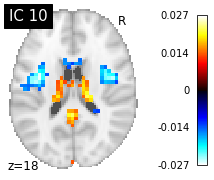

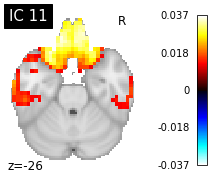

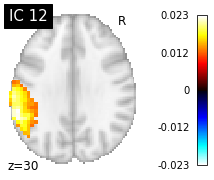

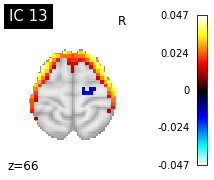

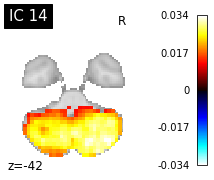

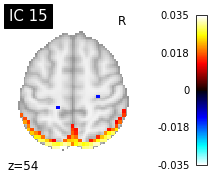

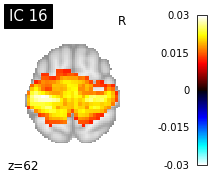

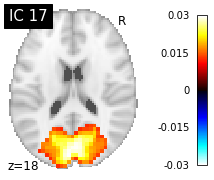

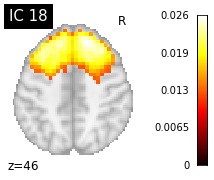

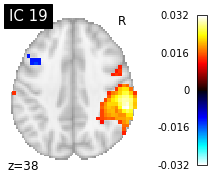

In [4]:
from nilearn.image import iter_img
from nilearn.plotting import plot_stat_map, show

for i, cur_img in enumerate(iter_img(canica_components_img)):
    plot_stat_map(cur_img, display_mode="z", title="IC %d" % i,
                  cut_coords=1, colorbar=True)
    
    

In [ ]:
from nilearn.decomposition import DictLearning

dict_learning = DictLearning(n_components=20,
                             memory="nilearn_cache", memory_level=2,
                             verbose=1,
                             random_state=0,
                             n_epochs=1,
                             mask_strategy='template')

print('[Example] Fitting dicitonary learning model')
dict_learning.fit(func_filenames)
print('[Example] Saving results')

# plase note the below porblem may have occur
# following info. plz check websise

# 測試0422


# Grab extracted components umasked back to Nifti image.
# Note: For older versions, less than 0.4.1. components_img_
# is not implemented. See Note section above for details.


dictlearning_components_img = dict_learning.components_img_
dictlearning_components_img.to_filename('dictionary_learning_resting_state.nii.gz')

# Dictionary Learning

dictlearning_components_img

F:\Users\pc\anaconda3\lib\site-packages\nilearn\plotting\displays.py:101: UserWarning: linewidths is ignored by contourf
  im = getattr(ax, type)(data_2d.copy(),
F:\Users\pc\anaconda3\lib\site-packages\nilearn\plotting\displays.py:101: UserWarning: No contour levels were found within the data range.
  im = getattr(ax, type)(data_2d.copy(),


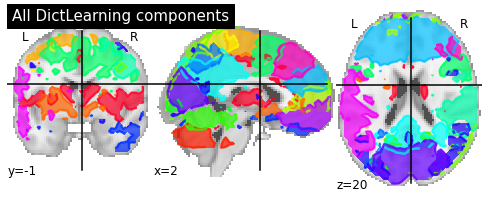

In [7]:
plot_prob_atlas(dictlearning_components_img,
                title='All DictLearning components')

## plotting dict

In [ ]:
for i, cur_img in enumerate(iter_img(dictlearning_components_img)):
    plot_stat_map(cur_img, display_mode="z", title="Comp %d" % i,
                  cut_coords=1, colorbar=True)

### dict_learning.score

by matplotlib

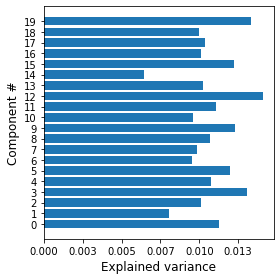

In [9]:
scores = dict_learning.score(func_filenames, per_component=True)

# Plot the scores

import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import FormatStrFormatter

# just comparative of all DLICs.
# itfollows websides tutorial.


plt.figure(figsize=(4, 4))
positions = np.arange(len(scores))
plt.barh(positions, scores)
plt.ylabel('Component #', size=12)
plt.xlabel('Explained variance', size=12)
plt.yticks(np.arange(20))
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
plt.tight_layout()

show()

## Extrating Regions

use for network connectomne

In [ ]:
# Import Region Extractor algorithm from regions module
# threshold=0.5 indicates that we keep nominal of amount nonzero voxels across all
# maps, less the threshold means that more intense non-voxels will be survived.
# 閾值可修改
# for preserve the best out come comparative with the turorial I haven't change


In [10]:
from nilearn.regions import RegionExtractor

extractor = RegionExtractor(dictlearning_components_img, threshold=0.5,
                            thresholding_strategy='ratio_n_voxels',
                            extractor='local_regions',
                            standardize=True, min_region_size=1350)

# Just call fit() to process for regions extraction
extractor.fit()

# Extracted regions are stored in regions_img_
regions_extracted_img = extractor.regions_img_

# Each region index is stored in index_
regions_index = extractor.index_

# Total number of regions extracted
n_regions_extracted = regions_extracted_img.shape[-1]

# Visualization of region extraction results
title = ('%d regions are extracted from %d components.'
         '\nEach separate color of region indicates extracted region'
         % (n_regions_extracted, 12))

# results()

F:\Users\pc\anaconda3\lib\site-packages\numpy\ma\core.py:2831: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


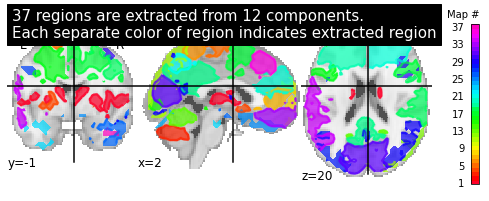

In [21]:
from nilearn import plotting

plotting.plot_prob_atlas(regions_extracted_img, view_type='filled_contours',
                         title=title, colorbar=True)

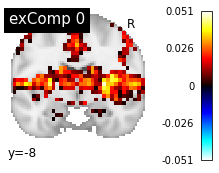

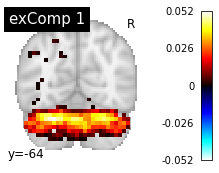

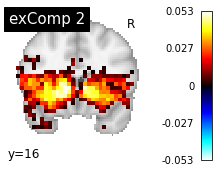

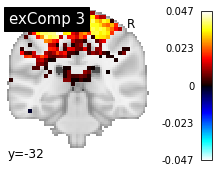

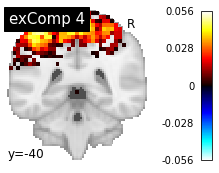

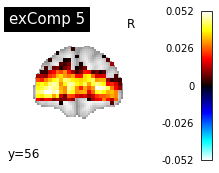

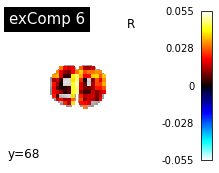

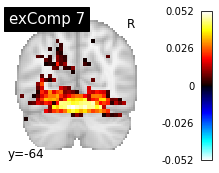

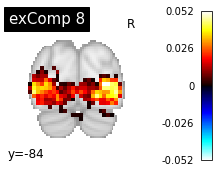

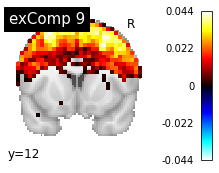

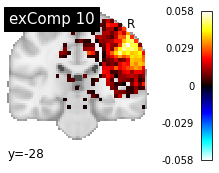

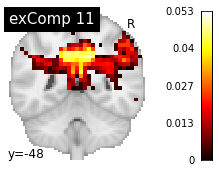

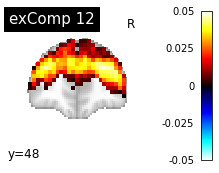

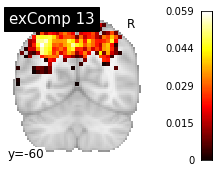

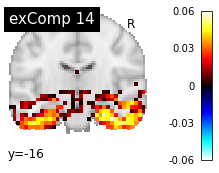

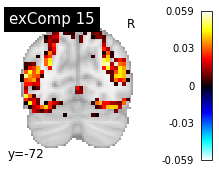

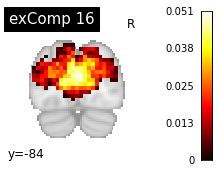

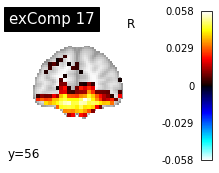

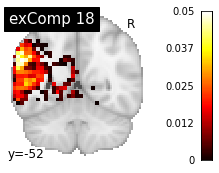

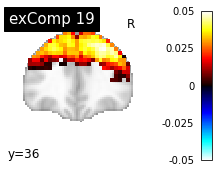

In [22]:
for j, cur_img in enumerate(iter_img(dictlearning_components_img)):
    plot_stat_map(cur_img, display_mode="y", title="exComp %d" % j,
                  cut_coords=1, colorbar=True)

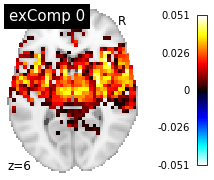

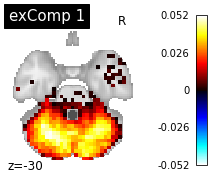

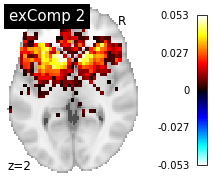

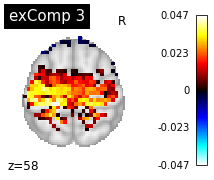

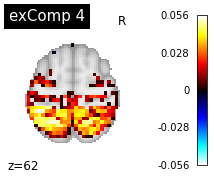

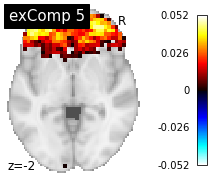

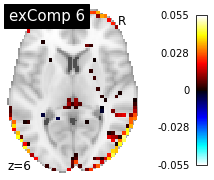

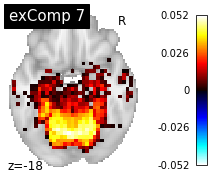

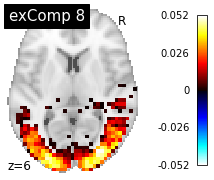

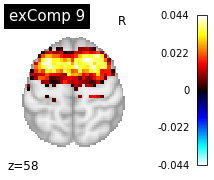

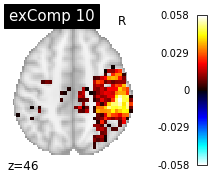

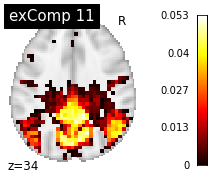

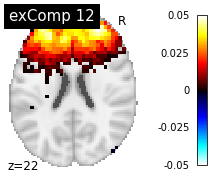

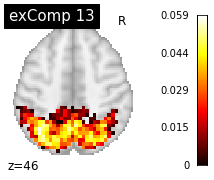

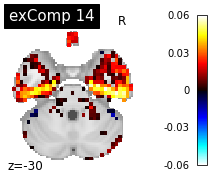

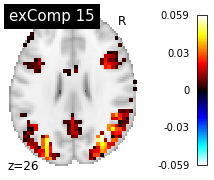

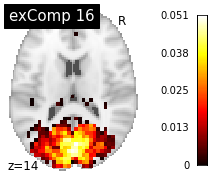

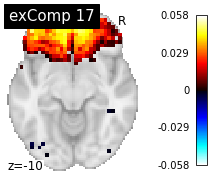

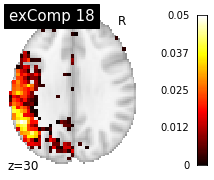

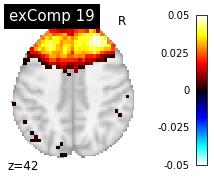

In [23]:
for j, cur_img in enumerate(iter_img(dictlearning_components_img)):
    plot_stat_map(cur_img, display_mode="z", title="exComp %d" % j,
                  cut_coords=1, colorbar=True)

In [ ]:
# First we need to do subjects timeseries signals extraction and then estimating
# correlation matrices on those signals.

# To extract timeseries signals, we call transform() from RegionExtractor object
# onto each subject functional data stored in func_filenames.

# To estimate correlation matrices we import connectome utilities from nilearn

In [24]:
from nilearn.connectome import ConnectivityMeasure
confounds = rest_dataset.confounds

correlations = []

# Initializing ConnectivityMeasure object with kind='correlation'
connectome_measure = ConnectivityMeasure(kind='correlation')
for filename, confound in zip(func_filenames, confounds):
    
    # call transform from RegionExtractor object to extract timeseries signals
    timeseries_each_subject = extractor.transform(filename, confounds=confound)
    
    # call fit_transform from ConnectivityMeasure object
    correlation = connectome_measure.fit_transform([timeseries_each_subject])
    
    # saving each subject correlation to correlations
    correlations.append(correlation)

# Mean of all correlations
import numpy as np
mean_correlations = np.mean(correlations, axis=0).reshape(n_regions_extracted,
                                                          n_regions_extracted)

In [25]:
mean_correlations

array([[ 1.        , -0.15657705,  0.08295416, ...,  0.02827156,
         0.14643293,  0.132149  ],
       [-0.15657705,  1.        ,  0.09462031, ..., -0.00497102,
         0.05321047,  0.02406557],
       [ 0.08295416,  0.09462031,  1.        , ...,  0.16956924,
         0.24817098,  0.15168663],
       ...,
       [ 0.02827156, -0.00497102,  0.16956924, ...,  1.        ,
         0.28426346,  0.28031608],
       [ 0.14643293,  0.05321047,  0.24817098, ...,  0.28426346,
         1.        ,  0.258771  ],
       [ 0.132149  ,  0.02406557,  0.15168663, ...,  0.28031608,
         0.258771  ,  1.        ]])

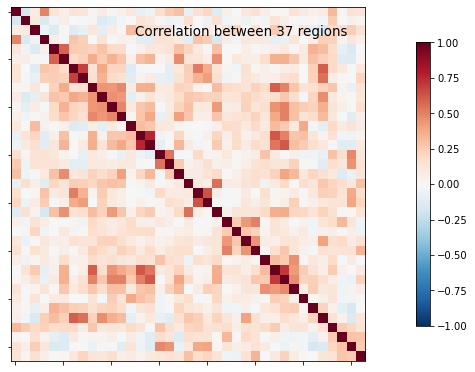

In [26]:
from nilearn import plotting

title = 'Correlation between %d regions' % n_regions_extracted

# First plot the matrix
display = plotting.plot_matrix(mean_correlations, vmax=1, vmin=-1, 
                                  colorbar=True,  
                                  title=title)

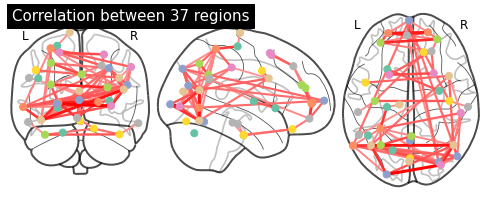

In [27]:
# Then find the center of the regions and plot a connectome

regions_img = regions_extracted_img
coords_connectome = plotting.find_probabilistic_atlas_cut_coords(regions_img)



plotting.plot_connectome(mean_correlations, coords_connectome,
                         edge_threshold='90%', title=title)

F:\Users\pc\anaconda3\lib\site-packages\numpy\ma\core.py:2831: UserWarning: Warning: converting a masked element to nan.
  _data = np.array(data, dtype=dtype, copy=copy,


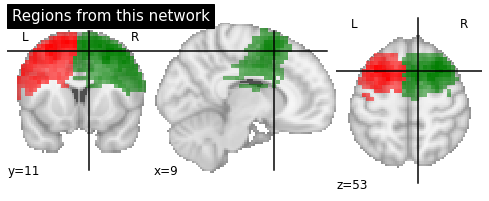

In [29]:
# For this, we take the indices of the all regions extracted related to original
# network given as 4.
regions_indices_of_map3 = np.where(np.array(regions_index) == 9)

display = plotting.plot_anat(cut_coords=coords,
                             title='Regions from this network'
                             )

# Add as an overlay all the regions of index 4
colors = 'rgbcmyk'
for each_index_of_map3, color in zip(regions_indices_of_map3[0], colors):
    display.add_overlay(image.index_img(regions_extracted_img, each_index_of_map3),
                        cmap=plotting.cm.alpha_cmap(color))

plotting.show()

In [30]:
view37 = plotting.view_connectome(
    mean_correlations, coords_connectome,
                         edge_threshold='90%', title=title)

view37